<a href="https://colab.research.google.com/github/trungnam844-droid/uber-fares-python-powerbi-analysis/blob/main/Uber.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
url = r"https://drive.google.com/file/d/13OYb9Dr7MP8_FYgkzDmmMNq2gMM2tXea/view?usp=drive_link"
file_id = url.split("/")[-2]
download_url = f"https://drive.google.com/uc?export=download&id={file_id}"
df = pd.read_csv(download_url)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         200000 non-null  int64  
 1   key                200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


In [3]:
df = df.drop(columns=['Unnamed: 0'])

In [4]:
df.isnull().sum()

,0
key,0
fare_amount,0
pickup_datetime,0
pickup_longitude,0
pickup_latitude,0
dropoff_longitude,1
dropoff_latitude,1
passenger_count,0


In [5]:
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 199999 entries, 0 to 199999
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   key                199999 non-null  object 
 1   fare_amount        199999 non-null  float64
 2   pickup_datetime    199999 non-null  object 
 3   pickup_longitude   199999 non-null  float64
 4   pickup_latitude    199999 non-null  float64
 5   dropoff_longitude  199999 non-null  float64
 6   dropoff_latitude   199999 non-null  float64
 7   passenger_count    199999 non-null  int64  
dtypes: float64(5), int64(1), object(2)
memory usage: 13.7+ MB


In [6]:
df.duplicated().sum()

np.int64(0)

**Rule for data:**

1. 0 < fare_amount < 200
2. 0 < passenger_count < 7
3. longitude : between (-180,180)

4. latitude : between (-90,90)


In [7]:
# Filter data
df = df[df['fare_amount'] > 0]
df = df[(df['passenger_count'] >= 1) & (df['passenger_count'] <= 6)]
df = df[
    (df['pickup_longitude'].between(-180,180)) &
    (df['pickup_latitude'].between(-90,90)) &
    (df['dropoff_longitude'].between(-180,180)) &
    (df['dropoff_latitude'].between(-90,90))
]

In [8]:
df.shape

(199256, 8)

In [9]:
df.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,199256.000000,199256.000000,199256.000000,199256.000000,199256.000000,199256.000000
mean,11.369376,-72.504173,39.919172,-72.514408,39.923484,1.689440
std,9.905986,10.442243,6.127757,10.403044,6.114307,1.305386
min,0.010000,-93.824668,-74.015515,-75.458979,-74.015750,1.000000
25%,6.000000,-73.992063,40.734794,-73.991409,40.733828,1.000000
50%,8.500000,-73.981825,40.752582,-73.980094,40.753041,1.000000
75%,12.500000,-73.967162,40.767155,-73.963663,40.767995,2.000000
max,499.000000,40.808425,48.018760,40.831932,45.031598,6.000000


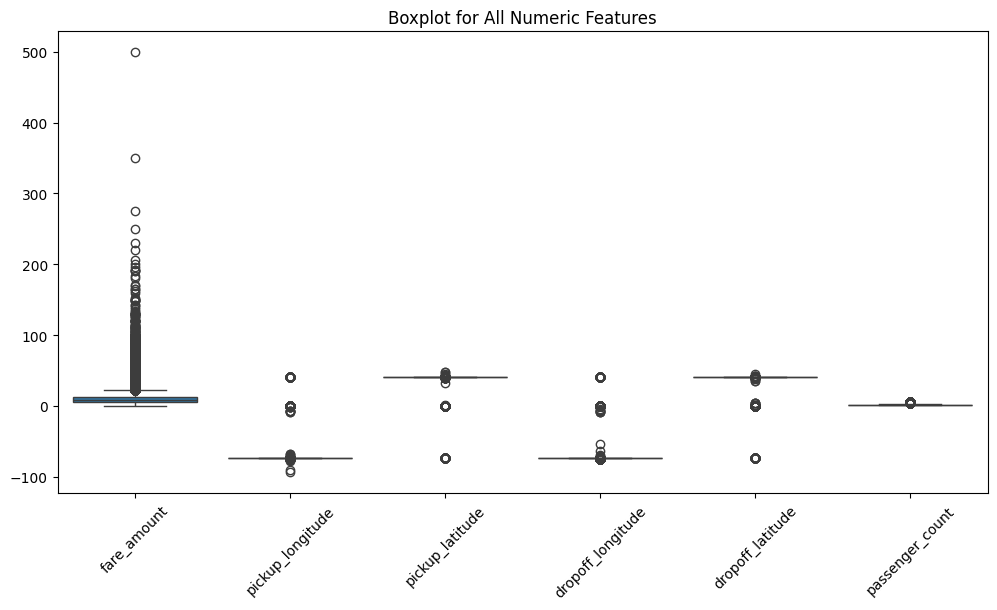

In [10]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df)
plt.title('Boxplot for All Numeric Features')
plt.xticks(rotation=45)
plt.show()

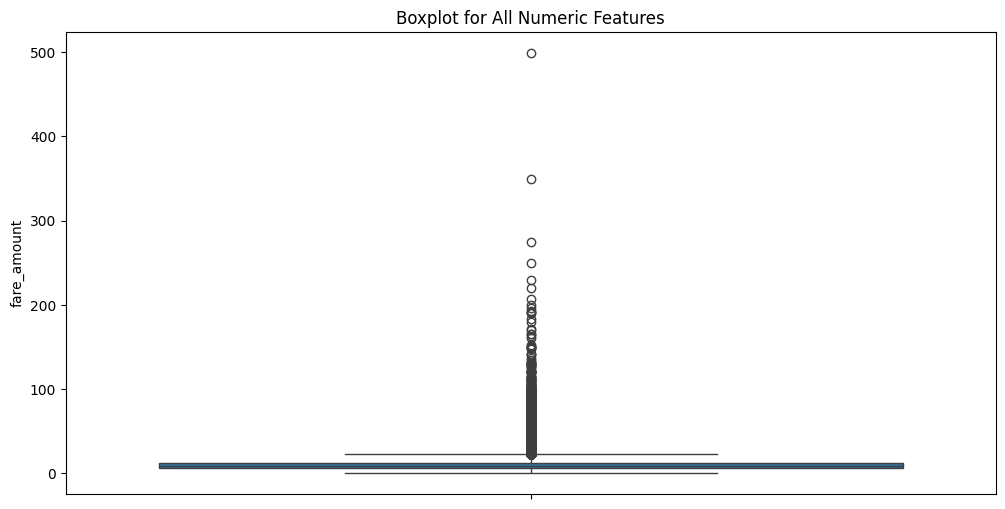

In [11]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df['fare_amount'])
plt.title('Boxplot for All Numeric Features')
plt.xticks(rotation=45)
plt.show()

In [12]:
def remove_outliers(df):
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        # Keep only rows within the bounds
        df = df[(df[col] >= lower) & (df[col] <= upper)]
    return df

# Apply the function
df_clean = remove_outliers(df)

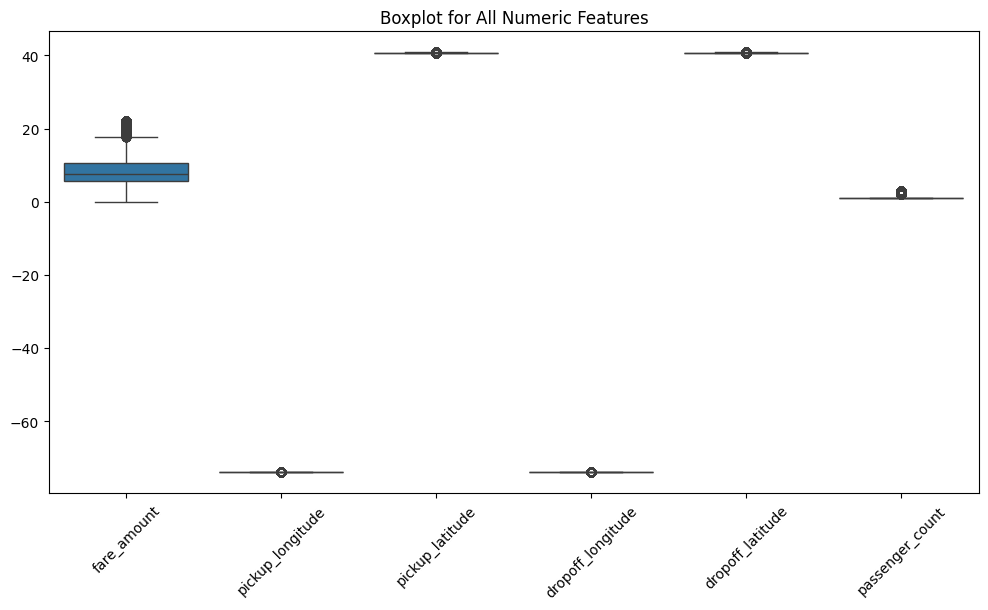

In [13]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_clean)
plt.title('Boxplot for All Numeric Features')
plt.xticks(rotation=45)
plt.show()

In [14]:
df_clean.shape

(147449, 8)

In [15]:
df_clean.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,147449.000000,147449.000000,147449.000000,147449.000000,147449.000000,147449.000000
mean,8.639595,-73.981890,40.752719,-73.981008,40.753033,1.266302
std,3.873721,0.016036,0.021132,0.016725,0.022261,0.544662
min,0.010000,-74.026353,40.692925,-74.025485,40.692085,1.000000
25%,5.700000,-73.992805,40.738173,-73.992251,40.738168,1.000000
50%,7.700000,-73.982857,40.753468,-73.982017,40.754152,1.000000
75%,10.500000,-73.971495,40.766680,-73.970447,40.767438,1.000000
max,22.200000,-73.934154,40.810923,-73.934753,40.812945,3.000000


In [16]:
df_clean['pickup_datetime'] = pd.to_datetime(df_clean['pickup_datetime'], errors='coerce')


df_clean['hour'] = df_clean['pickup_datetime'].dt.hour
df_clean['day'] = df_clean['pickup_datetime'].dt.day
df_clean['month'] = df_clean['pickup_datetime'].dt.month
df_clean['year'] = df_clean['pickup_datetime'].dt.year
df_clean['weekday'] = df_clean['pickup_datetime'].dt.weekday
df_clean['weekday_name'] = df_clean['pickup_datetime'].dt.day_name()

df_clean = df_clean.drop(columns=['pickup_datetime'])

In [17]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 147449 entries, 0 to 199999
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   key                147449 non-null  object 
 1   fare_amount        147449 non-null  float64
 2   pickup_longitude   147449 non-null  float64
 3   pickup_latitude    147449 non-null  float64
 4   dropoff_longitude  147449 non-null  float64
 5   dropoff_latitude   147449 non-null  float64
 6   passenger_count    147449 non-null  int64  
 7   hour               147449 non-null  int32  
 8   day                147449 non-null  int32  
 9   month              147449 non-null  int32  
 10  year               147449 non-null  int32  
 11  weekday            147449 non-null  int32  
 12  weekday_name       147449 non-null  object 
dtypes: float64(5), int32(5), int64(1), object(2)
memory usage: 12.9+ MB


In [18]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371

    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2) * np.sin(dlon/2)**2
    c = 2*np.arcsin(np.sqrt(a))

    return R*c

df_clean['distance_km'] = haversine(
    df_clean['pickup_latitude'],
    df_clean['pickup_longitude'],
    df_clean['dropoff_latitude'],
    df_clean['dropoff_longitude']
)

In [19]:
df_clean.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,month,year,weekday,distance_km
count,147449.000000,147449.000000,147449.000000,147449.000000,147449.000000,147449.000000,147449.000000,147449.000000,147449.000000,147449.000000,147449.000000,147449.000000
mean,8.639595,-73.981890,40.752719,-73.981008,40.753033,1.266302,13.640574,15.695820,6.253749,2011.712239,3.019654,2.346204
std,3.873721,0.016036,0.021132,0.016725,0.022261,0.544662,6.347823,8.682986,3.446847,1.860833,1.935120,1.608626
min,0.010000,-74.026353,40.692925,-74.025485,40.692085,1.000000,0.000000,1.000000,1.000000,2009.000000,0.000000,0.000000
25%,5.700000,-73.992805,40.738173,-73.992251,40.738168,1.000000,9.000000,8.000000,3.000000,2010.000000,1.000000,1.178377
50%,7.700000,-73.982857,40.753468,-73.982017,40.754152,1.000000,14.000000,16.000000,6.000000,2012.000000,3.000000,1.920796
75%,10.500000,-73.971495,40.766680,-73.970447,40.767438,1.000000,19.000000,23.000000,9.000000,2013.000000,5.000000,3.087350
max,22.200000,-73.934154,40.810923,-73.934753,40.812945,3.000000,23.000000,31.000000,12.000000,2015.000000,6.000000,12.339243


In [20]:
# remove same location
df_clean = df_clean[
    (df_clean['pickup_latitude'] != df_clean['dropoff_latitude']) |
    (df_clean['pickup_longitude'] != df_clean['dropoff_longitude'])
]

# remove extremely small trips
df_clean = df_clean[df_clean['distance_km'] > 0.1]

# remove unrealistic long trips
df_clean = df_clean[df_clean['distance_km'] < 50]

In [21]:
df_clean.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,month,year,weekday,distance_km
count,145551.000000,145551.000000,145551.000000,145551.000000,145551.000000,145551.000000,145551.000000,145551.000000,145551.000000,145551.000000,145551.000000,145551.000000
mean,8.666365,-73.981931,40.752729,-73.981038,40.753048,1.266903,13.642318,15.693736,6.252345,2011.716354,3.019807,2.376642
std,3.863718,0.015987,0.021121,0.016688,0.022265,0.545147,6.347248,8.682885,3.446716,1.861407,1.934673,1.596696
min,0.010000,-74.026353,40.692925,-74.025485,40.692085,1.000000,0.000000,1.000000,1.000000,2009.000000,0.000000,0.100227
25%,5.700000,-73.992803,40.738178,-73.992243,40.738172,1.000000,9.000000,8.000000,3.000000,2010.000000,1.000000,1.203541
50%,7.700000,-73.982872,40.753477,-73.982019,40.754165,1.000000,14.000000,16.000000,6.000000,2012.000000,3.000000,1.943136
75%,10.500000,-73.971550,40.766714,-73.970502,40.767483,1.000000,19.000000,23.000000,9.000000,2013.000000,5.000000,3.110082
max,22.200000,-73.934154,40.810923,-73.934753,40.812945,3.000000,23.000000,31.000000,12.000000,2015.000000,6.000000,12.339243


In [22]:
# Price per km
df_clean['price_per_km'] = df_clean['fare_amount'] / df_clean['distance_km']
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 145551 entries, 0 to 199999
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   key                145551 non-null  object 
 1   fare_amount        145551 non-null  float64
 2   pickup_longitude   145551 non-null  float64
 3   pickup_latitude    145551 non-null  float64
 4   dropoff_longitude  145551 non-null  float64
 5   dropoff_latitude   145551 non-null  float64
 6   passenger_count    145551 non-null  int64  
 7   hour               145551 non-null  int32  
 8   day                145551 non-null  int32  
 9   month              145551 non-null  int32  
 10  year               145551 non-null  int32  
 11  weekday            145551 non-null  int32  
 12  weekday_name       145551 non-null  object 
 13  distance_km        145551 non-null  float64
 14  price_per_km       145551 non-null  float64
dtypes: float64(7), int32(5), int64(1), object(2)
memory usag

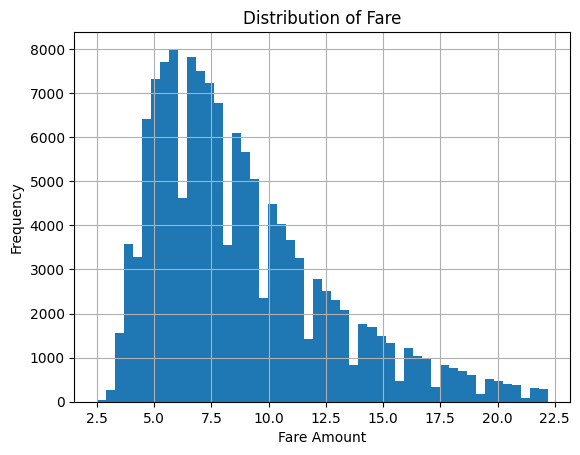

In [42]:
# Distribution of Fare
df_clean['fare_amount'].hist(bins=50)
plt.xlabel('Fare Amount')
plt.ylabel('Frequency')
plt.title('Distribution of Fare')
plt.show()

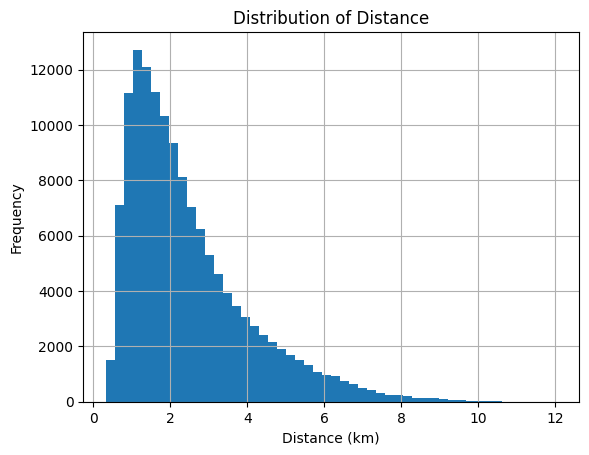

In [41]:
# Distribution of Distance
df_clean['distance_km'].hist(bins=50)
plt.xlabel('Distance (km)')
plt.ylabel('Frequency')
plt.title('Distribution of Distance')
plt.show()

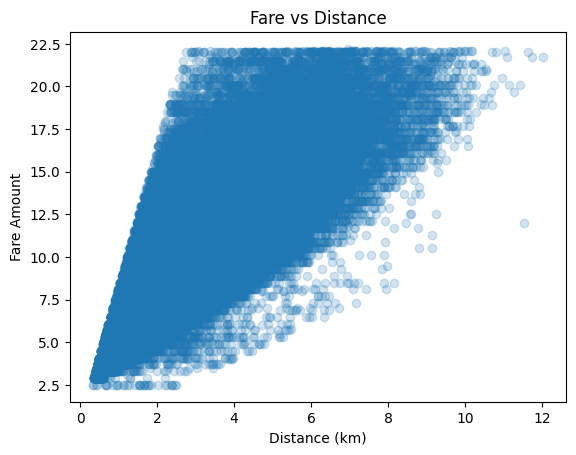

In [45]:
# Fare vs Distance
plt.scatter(df_clean['distance_km'], df_clean['fare_amount'], alpha=0.2)
plt.xlabel('Distance (km)')
plt.ylabel('Fare Amount')
plt.title('Fare vs Distance')
plt.show()

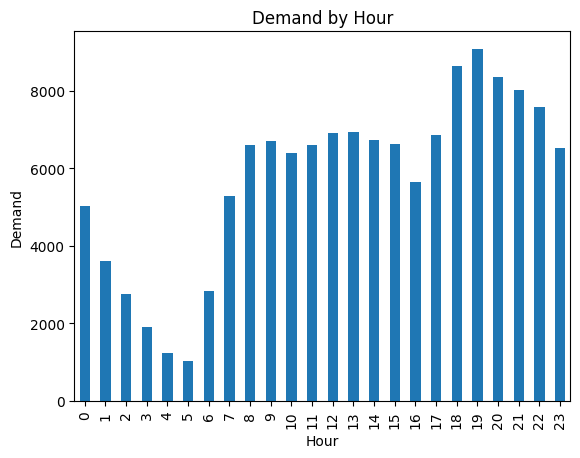

In [46]:
# Demand by Hour
df_clean.groupby('hour').size().plot(kind='bar')
plt.xlabel('Hour')
plt.ylabel('Demand')
plt.title('Demand by Hour')
plt.show()

In [27]:
df_clean = df_clean[[
  'key',
  'hour',
  'weekday',
  'weekday_name',
  'day',
  'month',
  'year',
  'passenger_count',
  'pickup_latitude',
  'pickup_longitude',
  'dropoff_latitude',
  'dropoff_longitude',
  'distance_km',
  'fare_amount',
  'price_per_km'
]]

In [28]:
df_clean["price_per_km"].describe()

,price_per_km
count,145551.000000
mean,4.596611
std,3.498550
min,0.001402
25%,3.127707
50%,3.976911
75%,5.191266
max,207.181749


In [29]:
# Remove Outlier for price_per_km

# Filter data
df_clean = df_clean[
    (df_clean['price_per_km'] > 1) &
    (df_clean['price_per_km'] < 20)
]

# Use IQR method
Q1 = df_clean['price_per_km'].quantile(0.25)
Q3 = df_clean['price_per_km'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_clean = df_clean[(df_clean['price_per_km'] >= lower) &
                    (df_clean['price_per_km'] <= upper)]

In [30]:
df_clean['price_per_km'].describe()

,price_per_km
count,137936.000000
mean,4.129996
std,1.374870
min,1.007472
25%,3.085719
50%,3.885943
75%,4.946692
max,8.237219


In [31]:
df_clean = df_clean.drop(columns=['key'])
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 137936 entries, 0 to 199999
Data columns (total 14 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   hour               137936 non-null  int32  
 1   weekday            137936 non-null  int32  
 2   weekday_name       137936 non-null  object 
 3   day                137936 non-null  int32  
 4   month              137936 non-null  int32  
 5   year               137936 non-null  int32  
 6   passenger_count    137936 non-null  int64  
 7   pickup_latitude    137936 non-null  float64
 8   pickup_longitude   137936 non-null  float64
 9   dropoff_latitude   137936 non-null  float64
 10  dropoff_longitude  137936 non-null  float64
 11  distance_km        137936 non-null  float64
 12  fare_amount        137936 non-null  float64
 13  price_per_km       137936 non-null  float64
dtypes: float64(7), int32(5), int64(1), object(1)
memory usage: 13.2+ MB


In [32]:
df_clean.to_csv('Uber_Clean.csv', index=False, encoding='utf-8-sig')